module://matplotlib_inline.backend_inline


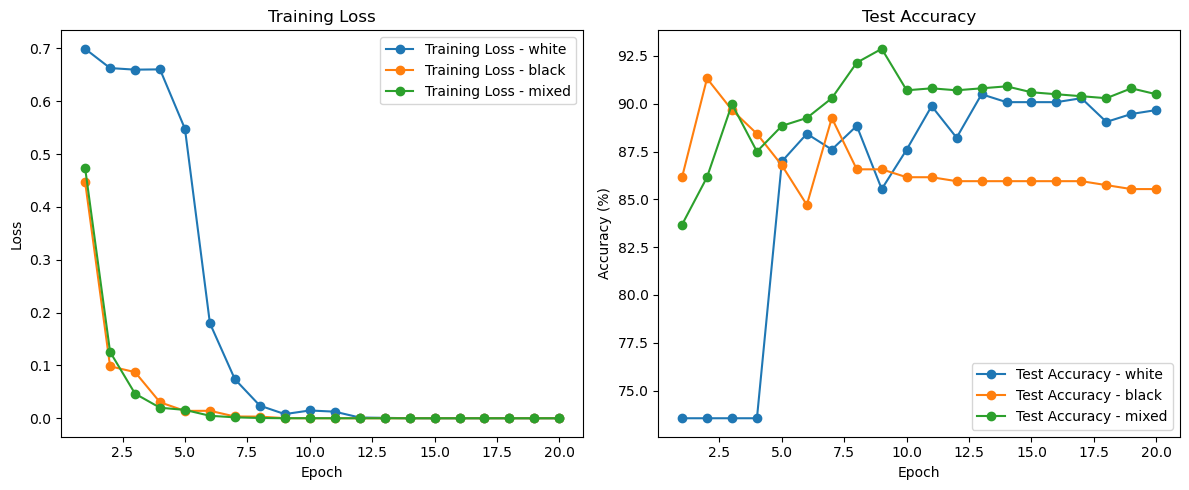

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib

output_directory = "./explained_images/"

def load_metrics_from_disk_with_exactFilename(train_loss_filename, test_accuracy_filename):
    train_loss_list = np.load(train_loss_filename)  # Load train_loss_list
    test_accuracy_list = np.load(test_accuracy_filename)  # Load test_accuracy_list
    return train_loss_list, test_accuracy_list
# Function to plot the loss and accuracy for multiple experiments
def plot_metrics_all_models(train_loss_lists, test_accuracy_lists, experiment_names):
    epochs = range(1, len(train_loss_lists[0]) + 1)
    #matplotlib.use('TkAgg')  # Or 'Qt5Agg', 'MacOSX' depending on your OS
    print(matplotlib.get_backend()) 
    plt.figure(figsize=(12, 5))
    
    # Plot all training loss curves
    for i, train_loss_list in enumerate(train_loss_lists):
        plt.subplot(1, 2, 1)
        plt.plot(epochs, train_loss_list, '-o', label=f'Training Loss - {experiment_names[i]}')
    plt.title('Training Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    # Plot all test accuracy curves
    for i, test_accuracy_list in enumerate(test_accuracy_lists):
        plt.subplot(1, 2, 2)
        plt.plot(epochs, test_accuracy_list, '-o', label=f'Test Accuracy - {experiment_names[i]}')
    plt.title('Test Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy (%)')
    plt.legend()

    plt.tight_layout()
    plt.savefig(os.path.join(output_directory, " metrics_all_experiments1.png"), dpi=300)
    plt.show()    

# Example usage:
train_loss_list_black,  test_accuracy_list_black = load_metrics_from_disk_with_exactFilename(
    os.path.join("./saved_metrics", "black" + " " + "trainLoss" + ".npy"), os.path.join("./saved_metrics", "black" + " " + "testAccuracy" + ".npy"))
train_loss_list_white,  test_accuracy_list_white = load_metrics_from_disk_with_exactFilename(
    os.path.join("./saved_metrics", "white" + " " + "trainLoss" + ".npy"), os.path.join("./saved_metrics", "white" + " " + "testAccuracy" + ".npy"))
train_loss_list_mixed, test_accuracy_list_mixed = load_metrics_from_disk_with_exactFilename(
    os.path.join("./saved_metrics", "mixed" + " " + "trainLoss" + ".npy"), os.path.join("./saved_metrics", "mixed" + " " + "testAccuracy" + ".npy"))
train_loss_lists = [train_loss_list_white, train_loss_list_black, train_loss_list_mixed]
test_accuracy_lists = [test_accuracy_list_white, test_accuracy_list_black, test_accuracy_list_mixed]
experiment_names = ['white', 'black', 'mixed']

plot_metrics_all_models(train_loss_lists, test_accuracy_lists, experiment_names)
